In [6]:
import h5py
import helpers
import numpy as np
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import Sampler
import os.path as osp
import os

from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import numpy as np


from nets import *

In [37]:
class H5Dataset(Dataset):
    def __init__(self, cosmo_h5_file_paths, 
                 gal_h5_file_paths, 
                 use_cache=False,
                 loadcache=False,
                 root="/data101/makinen/hirax_sims/dataloader/"):
        
        self.cosmo_h5_file_paths = cosmo_h5_file_paths
        self.gal_h5_file_paths = gal_h5_file_paths
        self.use_cache = use_cache

        self.cosmo_samples = []
        self.gal_samples = []
        
        
        # gather lists of cosmo and galaxy samples
        for i,path in enumerate(cosmo_h5_file_paths):
            # each index becomes the key
            h5_file = h5py.File(path, 'r')
            self.cosmo_samples.append({'file': h5_file, 'key': i})
                        
        for path in gal_h5_file_paths:
            h5_file = h5py.File(path, 'r')
            self.gal_samples.append({'file': h5_file})
        
        
        # initialise a random index for the galaxy samples
        self.gal_indices = torch.randperm(len(gal_h5_file_paths))
        self.len_gal = len(gal_h5_file_paths)
                
        self.root = root
        
        # check to see if the root dir and x and y cache are there
        # and load 
        if loadcache:
            if osp.exists(root + "gal_cache.pt"):
                print("loading cache dataset from disk")
                self.load_cache()

        else:
            self.gal_cache = []
            self.cosmo_cache = []
        

    # the length of the dataset is determined by the length of the cosmo map dataset
    def __len__(self):
        return len(self.cosmo_samples)

    # this method returns (x,y) = (cosmo + galaxy, cosmo) training pairs
    # here idx indexes the cosmology simulations (foregrounds will be random)
    def __getitem__(self, idx):
        
        if not self.use_cache:
            # choose the file to read in
            cosmo_sample_info = self.cosmo_samples[idx]
            cosmo_file = cosmo_sample_info['file']
            
            cosmo = torch.tensor(np.array(cosmo_file['/vis/']), dtype=torch.complex64)

            # add random foregrounds
            rand_idx = torch.randint(low=0, high=self.len_gal, size=()) #self.gal_indices[idx]
            gal_sample_info = self.gal_samples[rand_idx]

            gal_file = gal_sample_info['file']
            gal = torch.tensor(np.array(gal_file['/vis/']), dtype=torch.complex64)

            self.gal_cache.append(gal)
            self.cosmo_cache.append(cosmo)
            
            # now get x and y
            x = gal + cosmo
            y = cosmo
            
            
        else:
            # randomise foreground and cosmology combinations from cache
            rand_idx = torch.randint(low=0, high=self.len_gal, size=())
            gal = self.gal_cache[rand_idx] # random index from cache
            y = self.cosmo_cache[idx] # index of cosmological simulation
            x = gal + y
            
        return x, y
    
    def set_use_cache(self, use_cache):
        if use_cache & (not torch.is_tensor(self.gal_cache)):
            self.gal_cache = torch.stack(self.gal_cache)
            self.cosmo_cache = torch.stack(self.cosmo_cache)
        else:
            self.gal_cache = []
            self.cosmo_cache = []
        self.use_cache = use_cache
        
    
    def save_cache(self):
        if not osp.exists(self.root):
            os.makedirs(self.root)
        torch.save(torch.stack(self.gal_cache), self.root + "gal_cache.pt")
        torch.save(torch.stack(self.cosmo_cache), self.root + "cosmo_cache.pt")
        
    def load_cache(self):
        self.gal_cache = torch.load(self.root + "gal_cache.pt")
        self.cosmo_cache = torch.load(self.root + "cosmo_cache.pt")
        self.use_cache = True
        self.len_gal = self.gal_cache.shape[0]
    

    def __del__(self):
        for sample_info in self.cosmo_samples:
            sample_info['file'].close()
        
        for sample_info in self.gal_samples:
            sample_info['file'].close()

class InfiniteSampler(Sampler):
    def __init__(self, data_source):
        self.num_samples = len(data_source)

    def __iter__(self):
        while True:
            order = torch.randperm(self.num_samples)
            for i in range(self.num_samples):
                yield order[i]

    def __len__(self):
        return 2**31

In [3]:
cosmopath = "/data101/makinen/hirax_sims/cosmo_gaussian_pb/"
galpath = '/data101/makinen/hirax_sims/more_baselines/galaxy_gaussian_pb/'

In [4]:
cosmofiles = os.listdir(cosmopath)
galfiles = os.listdir(galpath)

In [ ]:
galaxy_mask = 1024

full_cosmo = cosmo_vis[:, :galaxy_mask, :, :]
full_gal = galaxy_vis[:, :galaxy_mask, :, :]
#full_obs = np.load(outdir + "obs_gauss.npy")[:, :galaxy_mask, :, :]

full_cosmo = np.transpose(full_cosmo, (0, 3, 1, 2))
full_gal = np.transpose(full_gal, (0, 3, 1, 2))

In [40]:
my_dataset = H5Dataset(cosmo_file_paths[:num], 
                       gal_file_paths[:num], 
                       use_cache=True,
                       loadcache=True)

my_dataloader.dataset.gal_cache.shape

loading cache dataset from disk


torch.Size([25, 48, 128, 2048])

loading cache dataset from disk


100%|██████████| 25/25 [00:00<00:00, 60.79it/s]


torch.Size([25, 48, 128, 2048])


100%|██████████| 25/25 [00:03<00:00,  6.69it/s]


cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal

KeyboardInterrupt: 

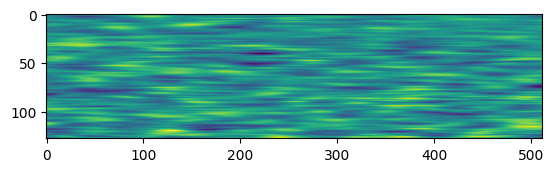

In [38]:
# Example usage
#cosmo_file_paths = ['cosmo_H0_60p894_vis_0.h5', 'cosmo_H0_69p3515_vis_54.h5']
cosmo_file_paths = [cosmopath + p for p in cosmofiles]

#gal_file_paths = ['galaxy_gsm_beta3p2_vis_31.h5',  'galaxy_md_beta3p2_vis_34.h5', 'galaxy_md_vis_45.h5', 'galaxy_md_beta3p2_vis_94.h5',  'galaxy_md_vis_94.h5']
gal_file_paths =  [galpath + p for p in galfiles]


batch_size = 5
num=25

# Create an instance of the custom dataset
my_dataset = H5Dataset(cosmo_file_paths[:num], 
                       gal_file_paths[:num], 
                       use_cache=True,
                       loadcache=True)

my_dataloader = DataLoader(
    my_dataset,
    num_workers=0,
    shuffle=False,
)

for data in tqdm(my_dataloader):
    pass
    #print(len(my_dataloader.dataset.gal_cache))
    
print(my_dataloader.dataset.gal_cache.shape)
    

# save the cache
#my_dataset.save_cache()


#my_dataloader.dataset.set_use_cache(use_cache=True)
my_dataloader.num_workers = 1
my_dataloader.prefetch_factor = 1

for data in tqdm(my_dataloader):
    #print(len(my_dataloader.dataset.gal_cache))
    pass

    
    
    
    

# Use an infinite sampler to continuously sample data
my_sampler = InfiniteSampler(my_dataset)

# Create a PyTorch DataLoader
my_dataloader = DataLoader(my_dataset, batch_size=batch_size, sampler=my_sampler)

# Iterate over batches
for batch in my_dataloader:
    x,y = batch
    
    print("cosmo", y.shape)
    print("gal + cosmo", x.shape)
    
    plt.imshow(np.array(y)[0, 0, :, :512].real)

    # Your training/validation/testing logic here
    # ...

# Don't forget to close the HDF5 files when you're done
#my_dataset.close()
